In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv("E:\\Ai\\edu\\Smart Learning Tracker\\data\\processed\\lesson_eval.csv")
df.head()

,student_id,course_id,lecture_id,watched,watch_time_min,quiz_score,attempts,mistake_type,time_spent,lesson_level
0,101,Math101,Lec1,1,6,72,3,calculation,29,medium
1,101,Math101,Lec2,1,5,56,1,concept,33,medium
2,101,Math101,Lec3,1,11,39,3,careless,42,weak
3,101,Math101,Lec4,1,54,68,2,concept,53,medium
4,101,Math101,Lec5,1,41,65,1,careless,37,medium


## 1. Overall Student Performance Levels per Stage

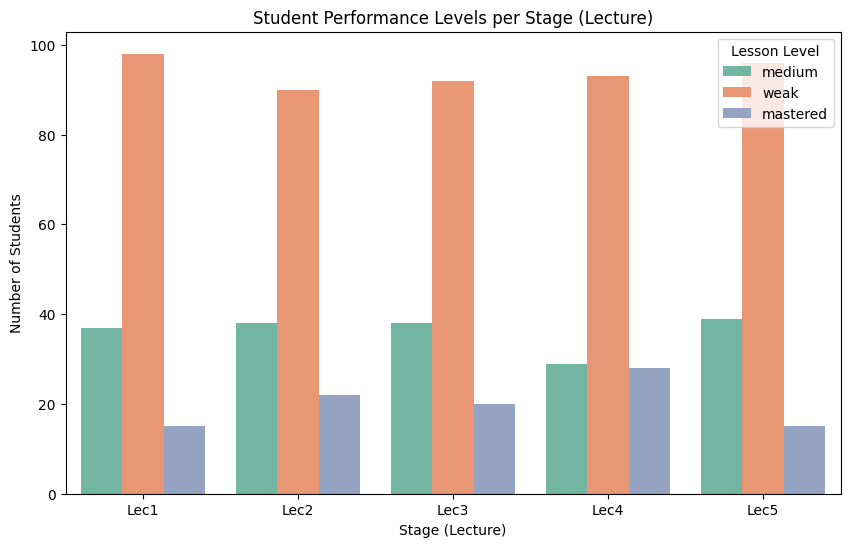

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='lecture_id', hue='lesson_level', palette='Set2')
plt.title('Student Performance Levels per Stage (Lecture)')
plt.xlabel('Stage (Lecture)')
plt.ylabel('Number of Students')
plt.legend(title='Lesson Level')
plt.show()

## 2. Average Score per Stage

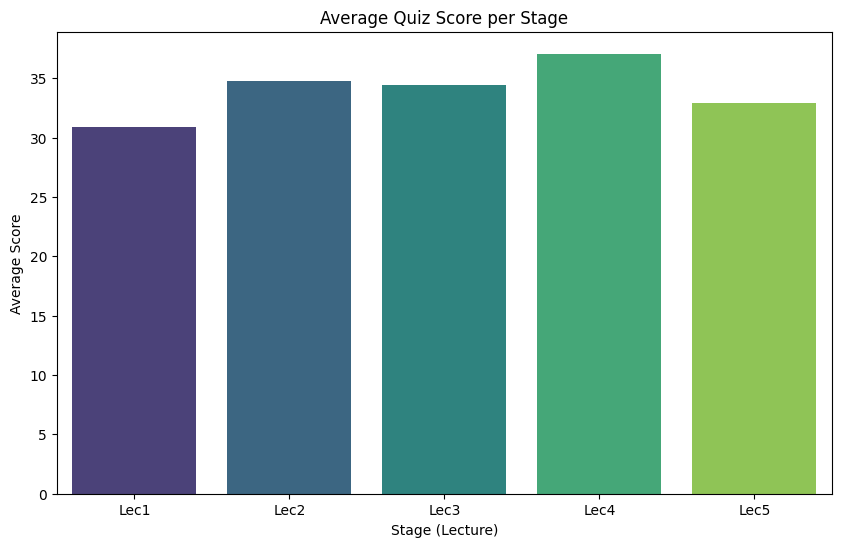

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='lecture_id', y='quiz_score', ci=None, palette='viridis')
plt.title('Average Quiz Score per Stage')
plt.xlabel('Stage (Lecture)')
plt.ylabel('Average Score')
plt.show()

## 3. Mistake Types per Stage


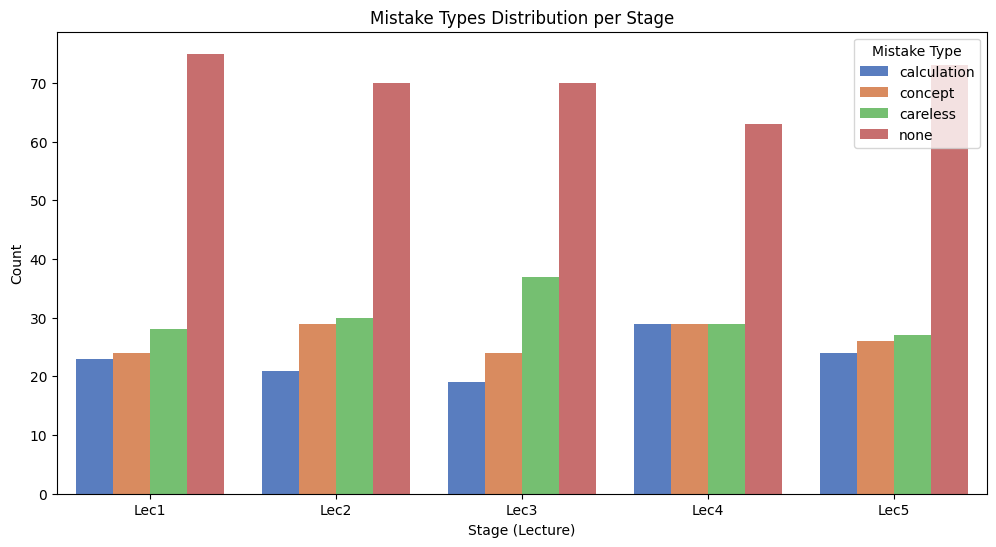

In [6]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='lecture_id', hue='mistake_type', palette='muted')
plt.title('Mistake Types Distribution per Stage')
plt.xlabel('Stage (Lecture)')
plt.ylabel('Count')
plt.legend(title='Mistake Type')
plt.show()

## 4. Visualizations لكل مرحلة (For Each Stage Individually)

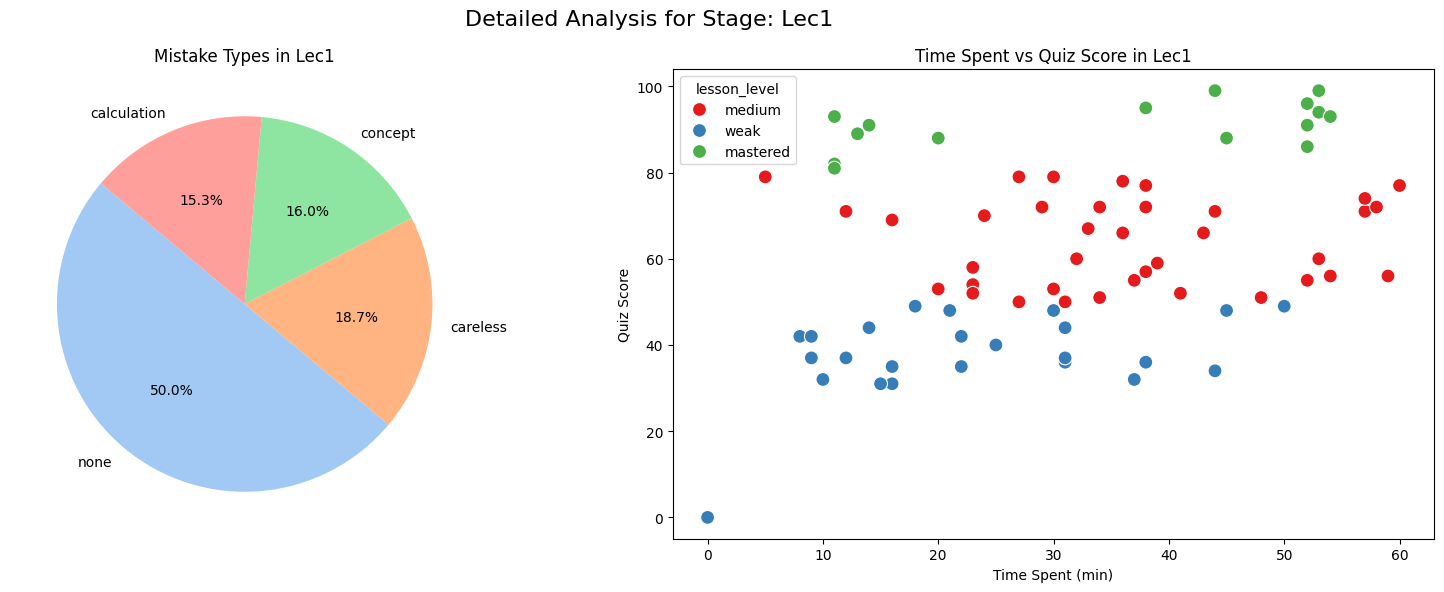

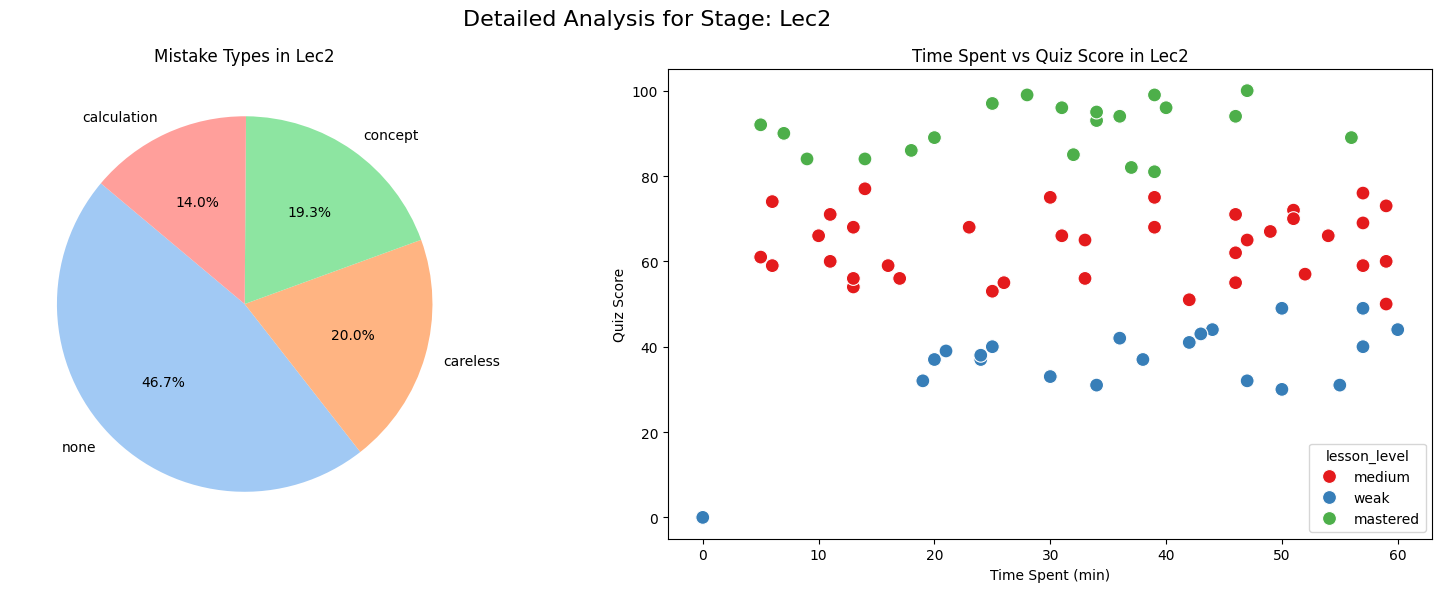

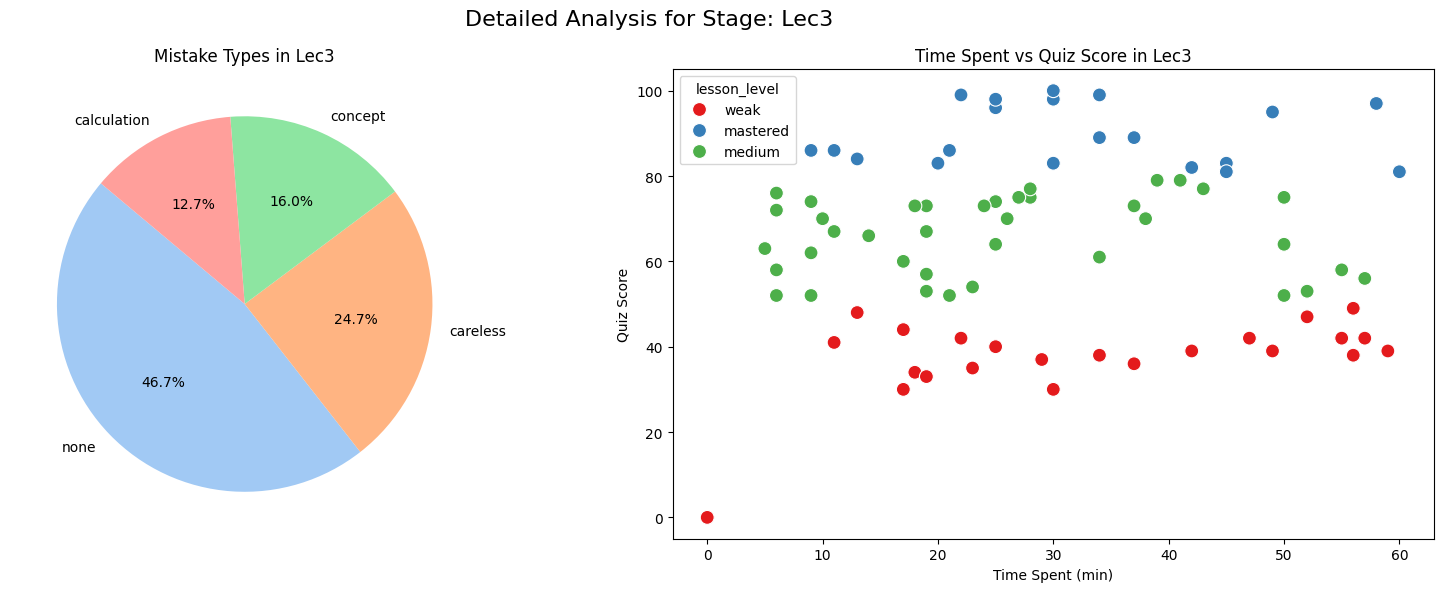

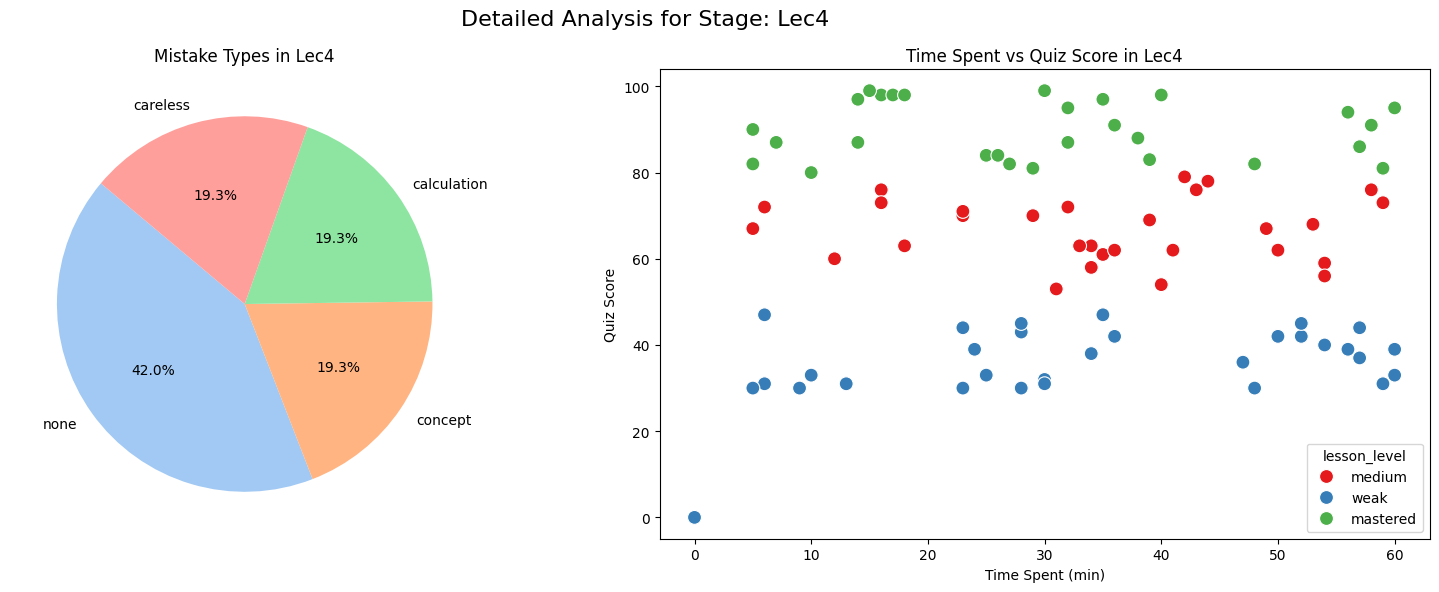

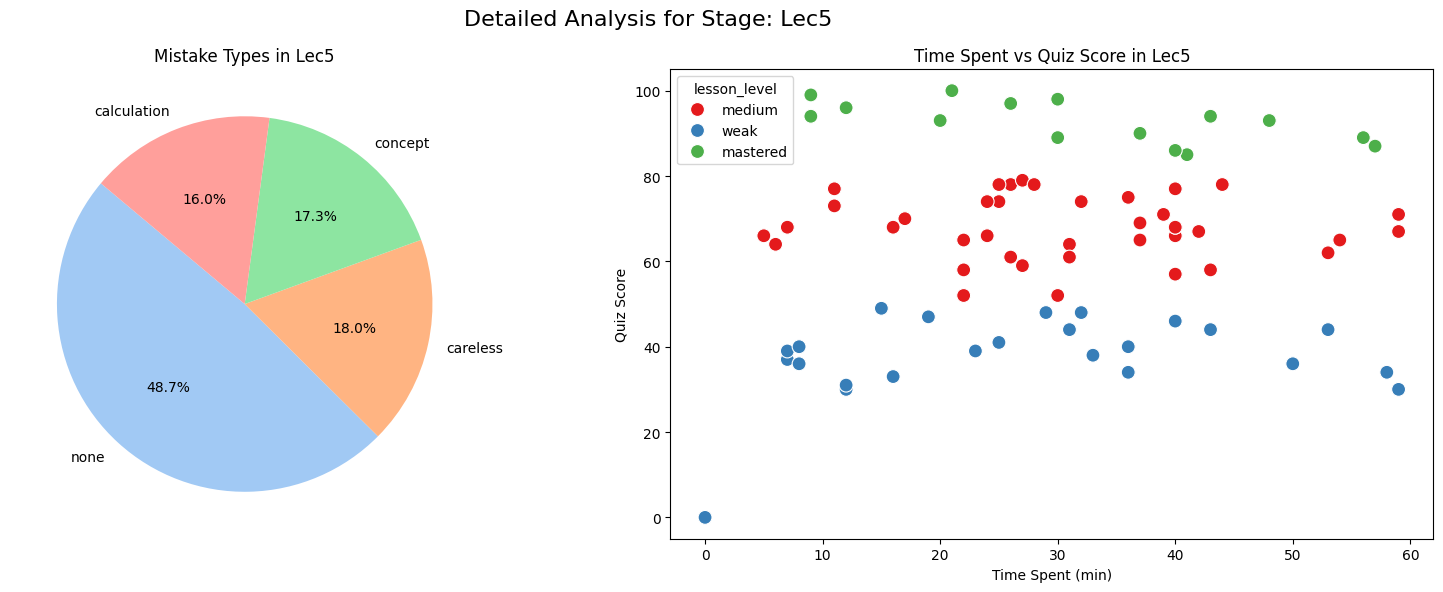

In [7]:
stages = sorted(df['lecture_id'].unique())

for stage in stages:
    stage_data = df[df['lecture_id'] == stage]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Detailed Analysis for Stage: {stage}', fontsize=16)
    
    # Pie Chart - Mistake Types
    mistakes_counts = stage_data['mistake_type'].value_counts()
    axes[0].pie(mistakes_counts, labels=mistakes_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    axes[0].set_title(f'Mistake Types in {stage}')
    
    # Scatter Plot - Time vs Score
    sns.scatterplot(data=stage_data, x='time_spent', y='quiz_score', hue='lesson_level', ax=axes[1], s=100, palette='Set1')
    axes[1].set_title(f'Time Spent vs Quiz Score in {stage}')
    axes[1].set_xlabel('Time Spent (min)')
    axes[1].set_ylabel('Quiz Score')
    
    plt.tight_layout()
    plt.show()